In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../Data/raw/Bengaluru_House_Data.csv")
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [3]:
df.shape

(13320, 9)

In [4]:
df.columns

Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [6]:
df.isnull().sum().sort_values(ascending=False)

society         5502
balcony          609
bath              73
size              16
location           1
area_type          0
availability       0
total_sqft         0
price              0
dtype: int64

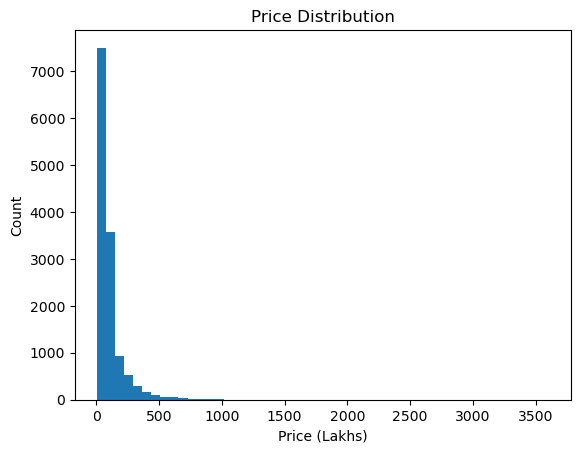

In [7]:
import matplotlib.pyplot as plt

plt.hist(df["price"], bins=50)
plt.title("Price Distribution")
plt.xlabel("Price (Lakhs)")
plt.ylabel("Count")
plt.show()

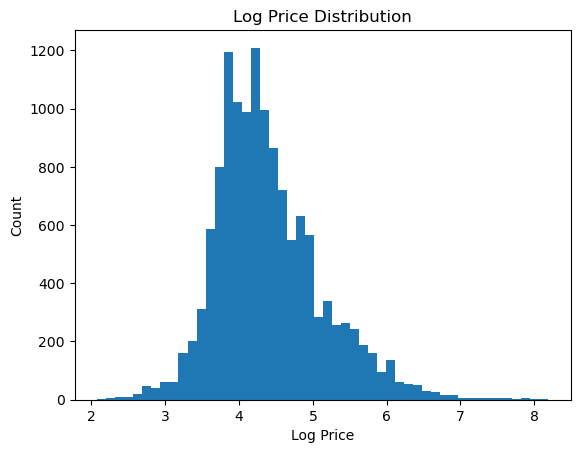

In [8]:
import numpy as np

df["log_price"] = np.log(df["price"])

plt.hist(df["log_price"], bins=50)
plt.title("Log Price Distribution")
plt.xlabel("Log Price")
plt.ylabel("Count")
plt.show()

In [9]:
df["total_sqft"].unique()[:30]

array(['1056', '2600', '1440', '1521', '1200', '1170', '2732', '3300',
       '1310', '1020', '1800', '2785', '1000', '1100', '2250', '1175',
       '1180', '1540', '2770', '600', '1755', '2800', '1767', '510',
       '1250', '660', '1610', '1151', '1025', '2100 - 2850'], dtype=object)

In [10]:
df["total_sqft"].sample(20)

477      4800
5163     1350
6345     1357
7436     1200
7865     3200
10790    1142
10955     600
5192     1246
7219     1044
10326    1255
8260     1215
2386     1760
7796     1015
7831     1890
57       1500
6819     1125
1067      929
97       1330
6943     1115
2134     1533
Name: total_sqft, dtype: object

In [11]:
# function to conver the total_sqft range to average 
def convert_sqft_to_num(x):
    if isinstance(x,str):
        if '-' in x:
            parts = x.split('-')
            return (float(parts[0])+ float(parts[1])) / 2
        try:
            return float(x)
        except:
            return None
    return None

In [12]:
df["total_sqft"] = df["total_sqft"].apply(convert_sqft_to_num)

In [13]:
df["total_sqft"].isnull().sum()

np.int64(46)

In [14]:
df[df["total_sqft"].isnull()]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,log_price
410,Super built-up Area,Ready To Move,Kengeri,1 BHK,NaN,NaN,1.0,0.0,18.50,2.917771
648,Built-up Area,Ready To Move,Arekere,9 Bedroom,NaN,NaN,9.0,NaN,265.00,5.579730
775,Built-up Area,Ready To Move,Basavanagara,1 BHK,NaN,NaN,2.0,1.0,93.00,4.532599
872,Super built-up Area,Ready To Move,Singapura Village,2 BHK,NaN,NaN,2.0,NaN,45.00,3.806662
1019,Plot Area,18-Mar,Marathi Layout,1 Bedroom,NaN,NaN,1.0,0.0,110.00,4.700480
1086,Plot Area,19-Mar,Narasapura,2 Bedroom,NaN,NaN,2.0,2.0,29.50,3.384390
1400,Super built-up Area,Ready To Move,Chamrajpet,9 BHK,NaN,NaN,9.0,1.0,296.00,5.690359
1712,Plot Area,Ready To Move,Singena Agrahara,3 Bedroom,CoiewSy,NaN,3.0,1.0,95.00,4.553877
1743,Super built-up Area,19-Mar,Hosa Road,3 BHK,Sosisic,NaN,3.0,1.0,115.00,4.744932
1821,Plot Area,Ready To Move,Sarjapur,3 Bedroom,Inensba,NaN,3.0,1.0,76.00,4.330733


In [15]:
df = df.dropna(subset=["total_sqft"])

In [16]:
df.shape

(13274, 10)

In [17]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5472
total_sqft         0
bath              73
balcony          605
price              0
log_price          0
dtype: int64

In [18]:
df = df .drop(columns=["society"])

In [19]:
df = df.dropna(subset=["size"])

In [20]:
df = df.dropna(subset=["location"])

In [21]:
df["bath"] = df["bath"].fillna(df["bath"].median())
df["balcony"] = df["balcony"].fillna(df["balcony"].median())

In [22]:
df.isnull().sum()

area_type       0
availability    0
location        0
size            0
total_sqft      0
bath            0
balcony         0
price           0
log_price       0
dtype: int64

In [23]:
df_numeric = df.select_dtypes(include=["float64","int64"])
df_numeric.corr()

,total_sqft,bath,balcony,price,log_price
total_sqft,1.000000,0.389850,0.154288,0.575632,0.559078
bath,0.389850,1.000000,0.207759,0.454334,0.613964
balcony,0.154288,0.207759,1.000000,0.125034,0.209597
price,0.575632,0.454334,0.125034,1.000000,0.775638
log_price,0.559078,0.613964,0.209597,0.775638,1.000000


In [24]:
df["price_per_sqft"] = (df["price"] * 100000) / df["total_sqft"]

In [25]:
df["price_per_sqft"].describe()

count    1.325700e+04
mean     7.912825e+03
std      1.064976e+05
min      2.678298e+02
25%      4.271186e+03
50%      5.438596e+03
75%      7.313318e+03
max      1.200000e+07
Name: price_per_sqft, dtype: float64

In [26]:
# now we will remove the outlier or range the values in average range from 1000 to 20000j per sqft
df = df[df["price_per_sqft"] < 20000]
df = df[df["price_per_sqft"] > 1000]

In [27]:
df.sort_values("price_per_sqft", ascending=False).head(5)

,area_type,availability,location,size,total_sqft,bath,balcony,price,log_price,price_per_sqft
2799,Plot Area,Ready To Move,Sarjapur Road,4 Bedroom,1152.0,4.0,1.0,230.0,5.438079,19965.277778
10485,Super built-up Area,18-Jul,Rajaji Nagar,5 BHK,7514.0,7.0,2.0,1500.0,7.313220,19962.736226
12742,Super built-up Area,18-Mar,Vasanth nagar,4 BHK,4750.0,6.0,1.0,948.0,6.854355,19957.894737
8682,Plot Area,Ready To Move,Yemlur,4 Bedroom,8400.0,5.0,2.0,1675.0,7.423568,19940.476190
3697,Plot Area,18-Mar,Yelahanka,4 Bedroom,4025.0,5.0,3.0,800.0,6.684612,19875.776398


In [28]:
df["bhk"] = df["size"].apply(lambda x: int(x.split(" ")[0]))

In [29]:
df[["size", "bhk"]].head()

,size,bhk
0,2 BHK,2
1,4 Bedroom,4
2,3 BHK,3
3,3 BHK,3
4,2 BHK,2


In [30]:
# now we will do the Domain-informed outlier removal
# but first we will inspect 
df[df["bath"] > df["bhk"] + 2]

,area_type,availability,location,size,total_sqft,bath,balcony,price,log_price,price_per_sqft,bhk
1078,Plot Area,Ready To Move,BTM 1st Stage,9 Bedroom,3300.0,14.0,2.0,500.0,6.214608,15151.515152,9
1953,Plot Area,Ready To Move,KR Puram,8 Bedroom,1200.0,12.0,2.0,110.0,4.700480,9166.666667,8
1979,Plot Area,Ready To Move,Hongasandra,8 Bedroom,990.0,12.0,0.0,120.0,4.787492,12121.212121,8
2620,Super built-up Area,Ready To Move,Sathya Sai Layout,6 BHK,11338.0,9.0,1.0,1000.0,6.907755,8819.897689,6
7709,Built-up Area,Ready To Move,Chikkabanavar,4 Bedroom,2460.0,7.0,2.0,80.0,4.382027,3252.032520,4
8106,Plot Area,Ready To Move,Wilson Garden,8 Bedroom,1850.0,12.0,2.0,300.0,5.703782,16216.216216,8
9990,Plot Area,Ready To Move,Doddakannelli,6 Bedroom,1200.0,9.0,3.0,122.0,4.804021,10166.666667,6
10695,Plot Area,18-Feb,Electronic City,9 Bedroom,1200.0,13.0,2.0,150.0,5.010635,12500.000000,9
11366,Built-up Area,Ready To Move,Nagasandra,4 Bedroom,7000.0,8.0,2.0,450.0,6.109248,6428.571429,4
11645,Plot Area,Ready To Move,Chamrajpet,6 Bedroom,1500.0,9.0,3.0,230.0,5.438079,15333.333333,6


In [31]:
df.columns

Index(['area_type', 'availability', 'location', 'size', 'total_sqft', 'bath',
       'balcony', 'price', 'log_price', 'price_per_sqft', 'bhk'],
      dtype='object')

In [32]:
len(df[df["bath"] > df["bhk"] + 2])

11

In [33]:
# now we will remove the oulier of the bhk + 2
df = df[df["bath"] <= df["bhk"] + 2]

In [34]:
df.shape

(12963, 11)

Now we will do the filtering of the Location variable  


In [35]:
df["location"].unique()

array(['Electronic City Phase II', 'Chikka Tirupathi', 'Uttarahalli', ...,
       '12th cross srinivas nagar banshankari 3rd stage',
       'Havanur extension', 'Abshot Layout'], dtype=object)

In [36]:
df["location"].nunique()

1269

In [37]:
df = df.copy()

In [38]:
# now we will remove the extra spaces
df["location"] = df["location"].str.strip()

In [39]:
df["location"].nunique()

1258

In [40]:
location_counts = df["location"].value_counts()
location_counts.head(15)

location
Whitefield                  535
Sarjapur  Road              396
Electronic City             302
Kanakpura Road              271
Thanisandra                 235
Yelahanka                   210
Uttarahalli                 184
Hebbal                      176
Marathahalli                175
Raja Rajeshwari Nagar       170
Hennur Road                 151
Bannerghatta Road           150
7th Phase JP Nagar          147
Haralur Road                140
Electronic City Phase II    131
Name: count, dtype: int64

In [41]:
len(location_counts[location_counts <= 10])

1023

In [42]:
location_counts.tail(20)

location
Mailasandra                         1
kanakapura main road                1
t.c palya                           1
Manganahalli                        1
Housing Board Layout Vijay Nagar    1
K R C kothanur                      1
1Channasandra                       1
Vijayabank bank layout              1
Saptagiri Layout                    1
Near ullas theater                  1
Basnashankari,6th stage,            1
Jaladarsini Layout                  1
N R Layout                          1
Subbannaiah Palya                   1
whitefiled                          1
Medi Agrahara                       1
CHIKKATIRUPATHI                     1
Sadduguntepalya                     1
Shirdi Sai Nagar                    1
Abshot Layout                       1
Name: count, dtype: int64

In [43]:
rare_locations = location_counts[location_counts <= 10].index

In [44]:
df["location"] = df["location"].apply(lambda x: "other" if x in rare_locations else x)

In [45]:
df["location"].nunique()

236

In [46]:
df = df.drop(columns=["availability"])

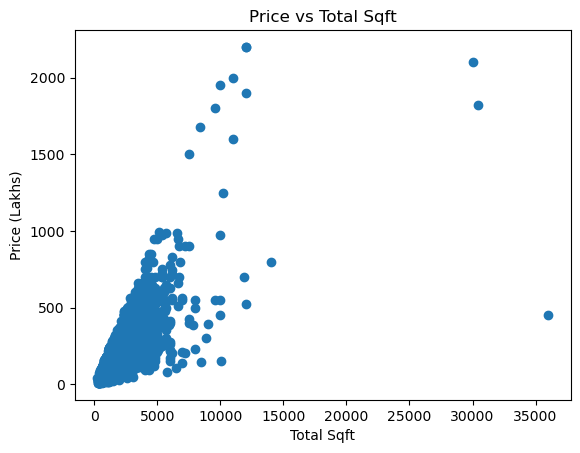

In [47]:
plt.scatter(df["total_sqft"], df["price"])
plt.xlabel("Total Sqft")
plt.ylabel("Price (Lakhs)")
plt.title("Price vs Total Sqft")
plt.show()

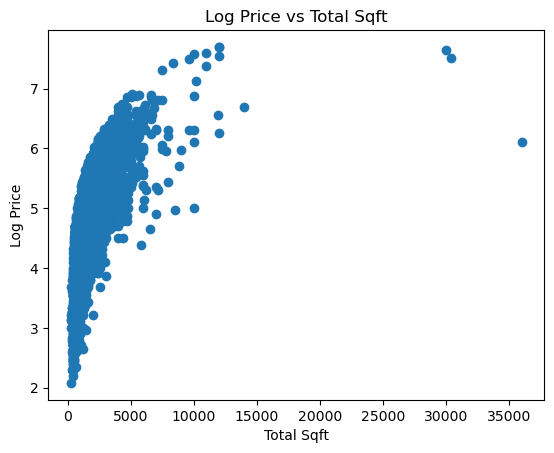

In [48]:
plt.scatter(df["total_sqft"], df["log_price"])
plt.xlabel("Total Sqft")
plt.ylabel("Log Price")
plt.title("Log Price vs Total Sqft")
plt.show()

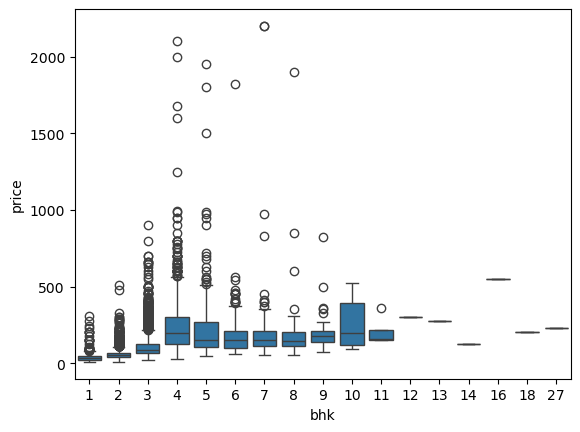

In [49]:
import seaborn as sns

sns.boxplot(x="bhk", y="price", data=df)
plt.show()

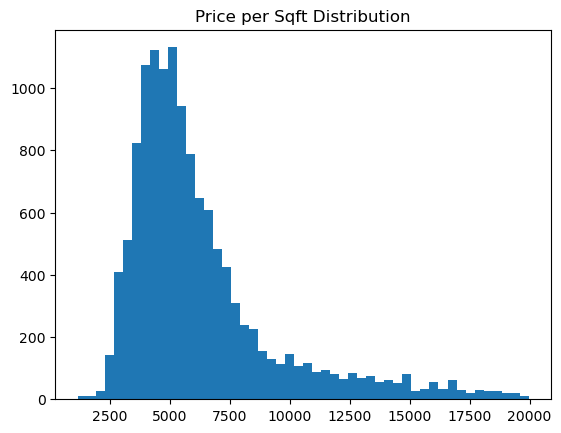

In [50]:
plt.hist(df["price_per_sqft"], bins=50)
plt.title("Price per Sqft Distribution")
plt.show()

In [51]:
X = df.drop(columns=["price", "log_price", "price_per_sqft"])
y = df["log_price"]

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [53]:
categorical_features = ["location","area_type"]
numerical_features = ["total_sqft","bath","balcony","bhk"]

In [54]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

In [55]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

from sklearn.linear_model import Ridge
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", Ridge(alpha=1.0))
    ]
)

from sklearn.ensemble import RandomForestRegressor

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [56]:
from sklearn.ensemble import RandomForestRegressor

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(
            n_estimators=100,
            max_depth=15,       # limit tree depth
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [57]:
model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [58]:
y_pred = model.predict(X_test)

In [59]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

rmse, r2

(np.float64(0.31455352226714905), 0.7716014540470146)

In [60]:
y_train_pred = model.predict(X_train)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

train_rmse, train_r2

(np.float64(0.2418240024238152), 0.8739773842151356)

In [61]:
model.fit(X,y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [62]:
import joblib
joblib.dump(model, "house_price_model.pkl")

['house_price_model.pkl']

In [63]:
loaded_model = joblib.load("house_price_model.pkl")

sample = X.iloc[[0]]  # single sample
prediction = loaded_model.predict(sample)

import numpy as np
np.exp(prediction)

array([41.60945068])

In [64]:
import os
os.getcwd()

'/Users/anujpandey/AiML_begins/house_price_prediction_ml/notebooks'

In [65]:
import os
import joblib

MODEL_PATH = os.path.join("..", "models", "house_price_model.pkl")

joblib.dump(model, MODEL_PATH)
print("Saved at:", os.path.abspath(MODEL_PATH))

Saved at: /Users/anujpandey/AiML_begins/house_price_prediction_ml/models/house_price_model.pkl


In [66]:
import joblib
import numpy as np

loaded_model = joblib.load("../models/house_price_model.pkl")

sample = X.iloc[[0]]   # single row dataframe
log_pred = loaded_model.predict(sample)[0]
price_pred = np.exp(log_pred)

price_pred

np.float64(41.60945067528921)

In [68]:
# Get trained objects
rf = model.named_steps["regressor"]
preprocessor = model.named_steps["preprocessor"]

# Numerical features
num_features = ["total_sqft", "bath", "balcony", "bhk"]

# Get categorical feature names after encoding
cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(["location", "area_type"])

# Combine all feature names
all_features = list(num_features) + list(cat_features)

# Get feature importances
importances = rf.feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    "feature": all_features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feature_importance_df.head(15)

,feature,importance
0,total_sqft,0.809772
3,bhk,0.051107
1,bath,0.045789
242,area_type_Plot Area,0.018648
2,balcony,0.012201
239,location_other,0.006611
194,location_Rajaji Nagar,0.005895
60,location_Chandapura,0.004885
240,area_type_Built-up Area,0.003822
149,location_Koramangala,0.002419


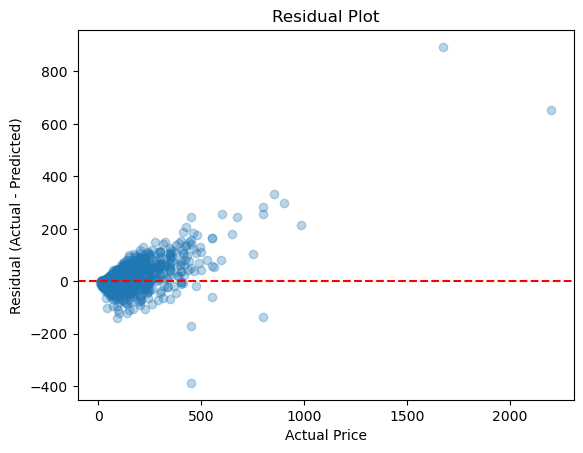

In [69]:
# Get predictions on test set
y_pred = model.predict(X_test)

# Convert from log scale
actual_prices = np.exp(y_test)
predicted_prices = np.exp(y_pred)

# Residuals
residuals = actual_prices - predicted_prices

# Plot
import matplotlib.pyplot as plt

plt.scatter(actual_prices, residuals, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Actual Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()

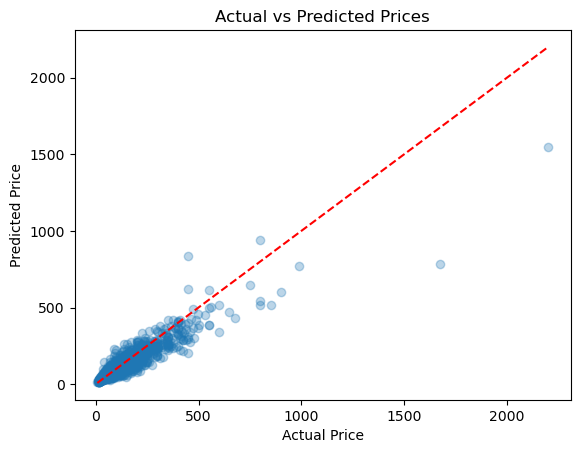

In [70]:
plt.scatter(actual_prices, predicted_prices, alpha=0.3)
plt.plot(
    [actual_prices.min(), actual_prices.max()],
    [actual_prices.min(), actual_prices.max()],
    'r--'
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

In [71]:
preprocessor = model.named_steps["preprocessor"]
encoder = preprocessor.named_transformers_["cat"]

location_categories = encoder.categories_[0]
area_type_categories = encoder.categories_[1]

location_categories[:10], area_type_categories

(array(['1st Block Jayanagar', '1st Phase JP Nagar',
        '2nd Phase Judicial Layout', '2nd Stage Nagarbhavi',
        '5th Phase JP Nagar', '6th Phase JP Nagar', '7th Phase JP Nagar',
        '8th Phase JP Nagar', '9th Phase JP Nagar', 'AECS Layout'],
       dtype=object),
 array(['Built-up  Area', 'Carpet  Area', 'Plot  Area',
        'Super built-up  Area'], dtype=object))